# Initial Exploratory Data Analysis

## 1. Dataset Overview

This notebook will perform an initial Exploratory Data Analysis (EDA) of the brain tumour MRI dataset. Analysis will include examining class distribution, image characteristics, data quality, and visual variation before model development.

In [2]:
from pathlib import Path

DATA_DIR = Path("../data")

## 2. Class Distribution

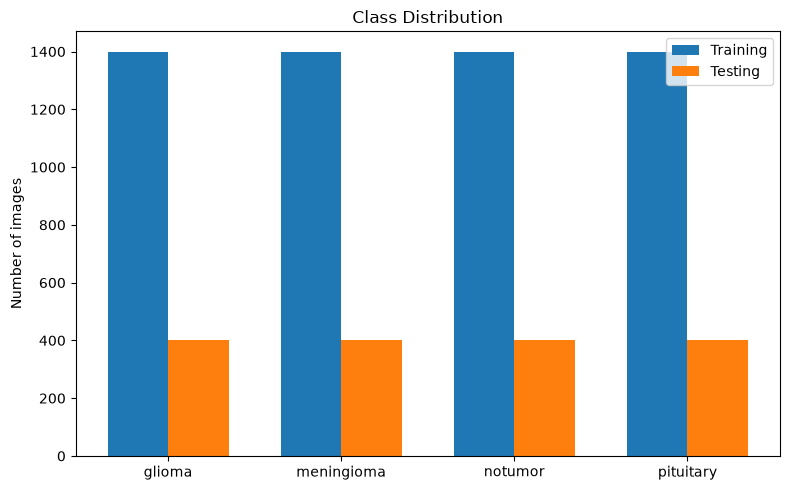

In [3]:
# Visualize the class distribution in the training and testing datasets

import matplotlib.pyplot as plt
import numpy as np

classes = ["glioma", "meningioma", "notumor", "pituitary"]

training_counts = []
testing_counts = []

for class_name in classes:
    training_counts.append(
        len([p for p in (DATA_DIR / "Training" / class_name).iterdir() if p.is_file()]) # Count the number of files in the training directory for each class
    )

    testing_counts.append(
        len([p for p in (DATA_DIR / "Testing" / class_name).iterdir() if p.is_file()]) # Count the number of files in the testing directory for each class
    )

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, training_counts, width, label="Training") # Create a bar chart for the training counts, offset to the left by half the width
plt.bar(x + width/2, testing_counts, width, label="Testing") # Create a bar chart for the testing counts, offset to the right by half the width

plt.xticks(x, classes)
plt.ylabel("Number of images")
plt.title("Class Distribution")
plt.legend()

plt.tight_layout()
plt.show()

### Observation

The class distribution is relatively balanced across the four classes, with the test set being around 22% of the total dataset (just take one of the categories as an example: 400 out of 1800), and the training set being around 78% of the total dataset (1400 out of 1800).

## 3. Sample Images

Several images from each class are shown below to visually examine differences in appearance, orientation, and image characteristics.

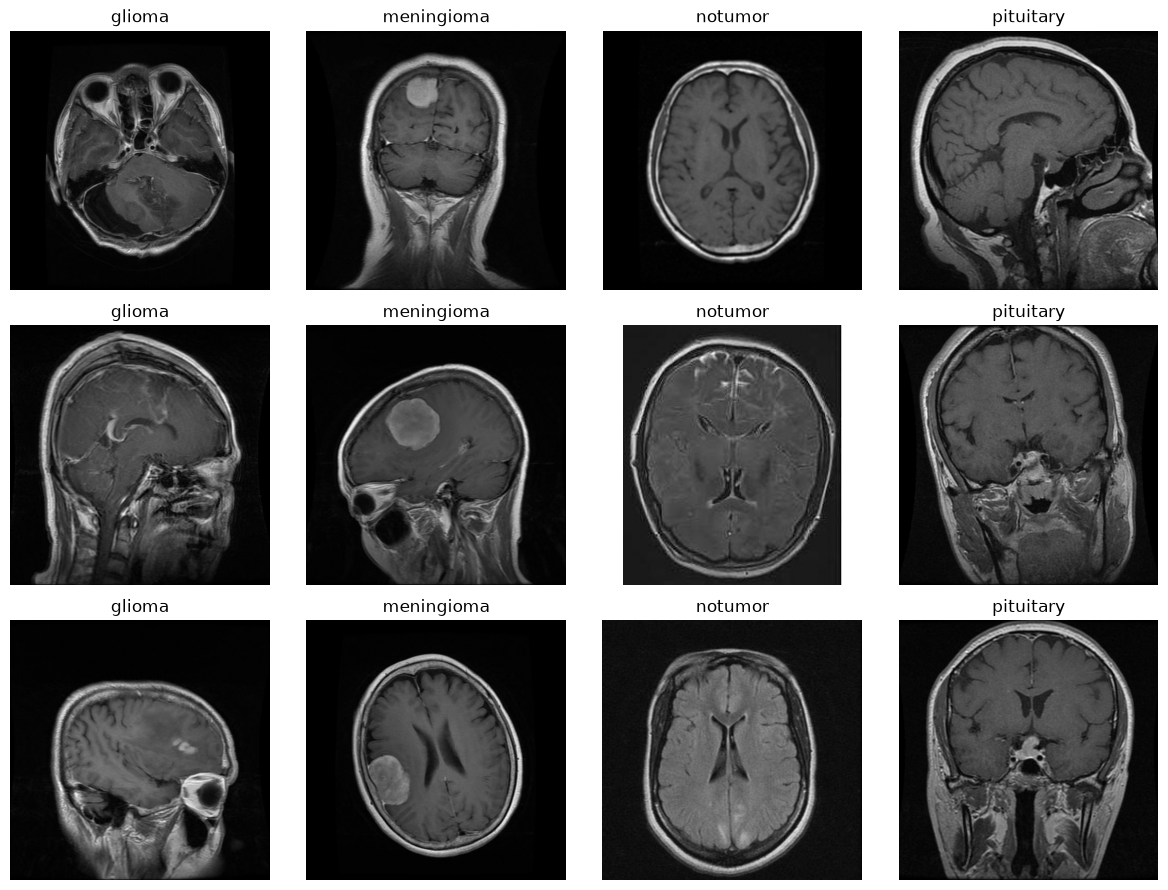

In [ ]:
# Visualize a few sample images from each class in the training dataset (will be random each time you run this cell)

import random
from PIL import Image

classes = ["glioma", "meningioma", "notumor", "pituitary"]

fig, axes = plt.subplots(3, 4, figsize=(12, 9)) # Create a figure with 3 rows and 4 columns of subplots

for col, class_name in enumerate(classes):
    image_paths = list((DATA_DIR / "Training" / class_name).glob("*"))
    samples = random.sample(image_paths, 3)

    for row, path in enumerate(samples):
        with Image.open(path) as img:
            axes[row, col].imshow(img.convert("L"), cmap="gray") # Set to gray for matplotlib to show accurate images
            # All images are still grayscale despite having different color modes

        axes[row, col].set_title(class_name)
        axes[row, col].axis("off") # Turn off axis labels and ticks for a cleaner look

plt.tight_layout()
plt.show()

### Observation

The sampled images were valid MRI images, however with variation in orientation, viewpoint, and appearance across samples. This variation will be considered during preprocessing and model evaluation.

## 4. Image Dimensions

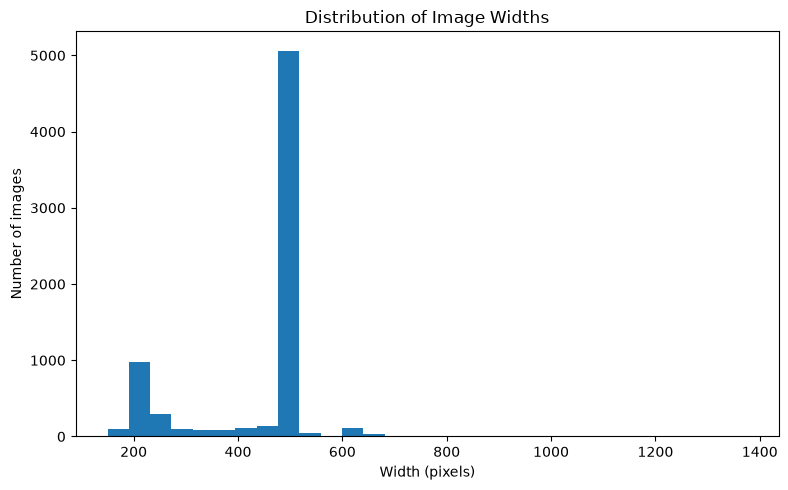

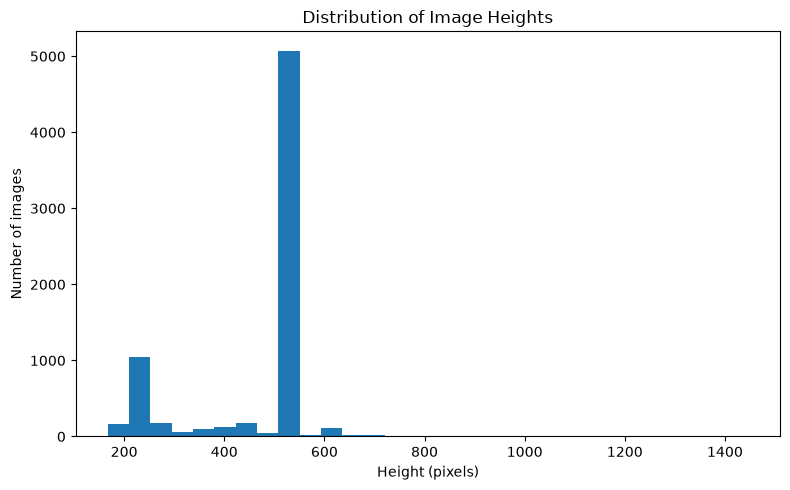

In [5]:
# Visualize the distribution of image widths and heights in the dataset

widths = []
heights = []

for path in DATA_DIR.rglob("*"):
    if path.is_file():
        try:
            with Image.open(path) as img:
                width, height = img.size
                widths.append(width)
                heights.append(height)
        except Exception:
            pass

# Visualize the distribution of image widths in the dataset
plt.figure(figsize=(8, 5))
plt.hist(widths, bins=30)
plt.xlabel("Width (pixels)")
plt.ylabel("Number of images")
plt.title("Distribution of Image Widths")
plt.tight_layout()
plt.show()

# Visualize the distribution of image heights in the dataset
plt.figure(figsize=(8, 5))
plt.hist(heights, bins=30)
plt.xlabel("Height (pixels)")
plt.ylabel("Number of images")
plt.title("Distribution of Image Heights")
plt.tight_layout()
plt.show()

### Observation

Image dimensions vary substantially across the dataset, with 512 × 512 being the most common resolution (you can check confirmation for this in the [Approval Notebook](./approval.ipynb)). Therefore, the images will require a consistent resizing strategy before being provided to the machine learning models.

## 5. Image Colour Properties

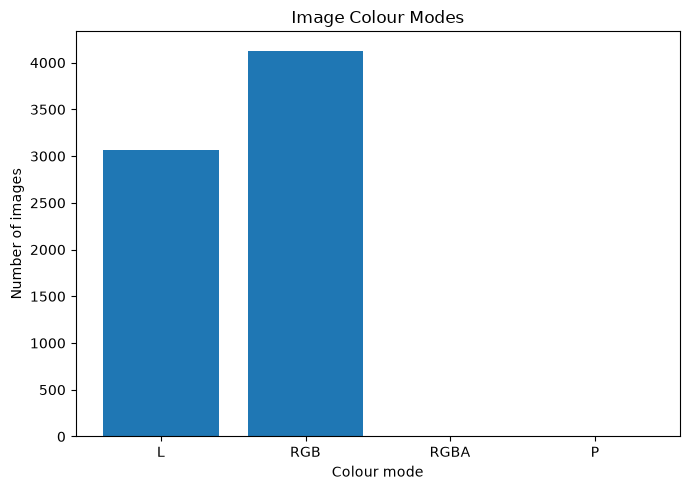

In [6]:
# Visualize the distribution of image colour modes in the dataset 

from collections import Counter

modes = Counter()

for path in DATA_DIR.rglob("*"):
    if path.is_file():
        try:
            with Image.open(path) as img:
                modes[img.mode] += 1
        except Exception:
            pass

plt.figure(figsize=(7, 5)) 
plt.bar(modes.keys(), modes.values())

plt.xlabel("Colour mode")
plt.ylabel("Number of images")
plt.title("Image Colour Modes")

plt.tight_layout()
plt.show()

### Observation

The dataset contains both grayscale and colour images. Most images use either the L (grayscale) or RGB colour mode, while only a small number use RGBA or palette-based colour encoding (can be confirmed in the [Approval Notebook](./approval.ipynb)). This inconsistency will need to be addressed during preprocessing.

## 6. Data Quality and Duplicates

The dataset was checked for unreadable/corrupt image files and exact duplicate files in the [Approval Notebook](./approval.ipynb).

| Check | Result |
|---|---|
| Corrupt files | 0 |
| Exact duplicate groups | 153 |

## 7. EDA Summary

The initial EDA identified several characteristics of the dataset that will influence preprocessing and model development:

- The dataset contains four target classes.
- The class distribution is balanced.
- Image resolutions vary across samples, with 512 × 512 being the most common.
- Images use multiple colour modes, primarily grayscale and RGB.
- The sampled images show variation in orientation, viewpoint, and appearance.
- There appear to be duplicate groups in the dataset.

These findings will be considered when developing the preprocessing pipeline and training the three machine learning models.